In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%pip install windrose
from windrose import WindroseAxes

Note: you may need to restart the kernel to use updated packages.


In [2]:
df1 = pd.read_excel('ADCP-Data_Deployment-Period1.xlsx', sheet_name='Station B',skiprows=17)
df2 = pd.read_excel('ADCP-Data_Deployment-Period2.xlsx', sheet_name='Station B-2',skiprows=17)

In [3]:
df = pd.concat([df1, df2], ignore_index=True)

columns_to_drop = [c for c in ['Date & Time', 'Date & Time.1', 'Unnamed: 3'] if c in df.columns]
df.drop(columns=columns_to_drop, inplace=True)

if 'Unnamed: 8' in df.columns:
    unnamed_8_index = df.columns.get_loc('Unnamed: 8')
    columns_to_drop = df.columns[unnamed_8_index:]
    df.drop(columns=columns_to_drop, inplace=True)

df = df.drop(index=[0, 1])
df.head()

,Date & Time.2,Eas,Nor,Mag,Dir
2,2024-10-23 09:00:00,185,69,197,70
3,2024-10-23 09:10:00,91,46,102,63
4,2024-10-23 09:20:00,13,34,36,20
5,2024-10-23 09:30:00,-79,9,80,277
6,2024-10-23 09:40:00,-175,-1,175,270


Merged deployments:

In [4]:
angles_deg = pd.to_numeric(df['Dir'], errors='coerce').to_numpy()
angles_deg = np.mod(angles_deg, 360)  # Normalize to [0, 360)
angles_deg = angles_deg[~np.isnan(angles_deg)]  # Drop NaNs

if angles_deg.size == 0:
    print("No valid direction values in 'Dir' column.")
else:
    ang_rad = np.deg2rad(angles_deg)
    mean_sin = np.mean(np.sin(ang_rad))
    mean_cos = np.mean(np.cos(ang_rad))
    mean_rad = np.arctan2(mean_sin, mean_cos)
    overall_mean_direction_deg = np.degrees(mean_rad) % 360
    print(f"Overall mean direction: {overall_mean_direction_deg:.2f} degrees")

Overall mean direction: 339.11 degrees


Deployment 1:

In [5]:
angles_deg = pd.to_numeric(df1['Dir'], errors='coerce').to_numpy()
angles_deg = np.mod(angles_deg, 360)  # Normalize to [0, 360)
angles_deg = angles_deg[~np.isnan(angles_deg)]  # Drop NaNs

if angles_deg.size == 0:
    print("No valid direction values in 'Dir' column.")
else:
    ang_rad = np.deg2rad(angles_deg)
    mean_sin = np.mean(np.sin(ang_rad))
    mean_cos = np.mean(np.cos(ang_rad))
    mean_rad = np.arctan2(mean_sin, mean_cos)
    overall_mean_direction_deg1 = np.degrees(mean_rad) % 360
    print(f"Overall mean direction: {overall_mean_direction_deg1:.2f} degrees")

Overall mean direction: 340.24 degrees


Deployment 2:

In [6]:
angles_deg = pd.to_numeric(df2['Dir'], errors='coerce').to_numpy()
angles_deg = np.mod(angles_deg, 360)  # Normalize to [0, 360)
angles_deg = angles_deg[~np.isnan(angles_deg)]  # Drop NaNs

if angles_deg.size == 0:
    print("No valid direction values in 'Dir' column.")
else:
    ang_rad = np.deg2rad(angles_deg)
    mean_sin = np.mean(np.sin(ang_rad))
    mean_cos = np.mean(np.cos(ang_rad))
    mean_rad = np.arctan2(mean_sin, mean_cos)
    overall_mean_direction_deg2 = np.degrees(mean_rad) % 360
    print(f"Overall mean direction: {overall_mean_direction_deg2:.2f} degrees")

Overall mean direction: 338.28 degrees


In [7]:
D1 = overall_mean_direction_deg - overall_mean_direction_deg1
D2 = overall_mean_direction_deg - overall_mean_direction_deg2
print(f"Orientation correction for Period 1: {D1:.2f} degrees")
print(f"Orientation correction for Period 2: {D2:.2f} degrees")

Orientation correction for Period 1: -1.13 degrees
Orientation correction for Period 2: 0.83 degrees


In [8]:
# Compare: Circular mean vs. Arithmetic mean
print("=" * 60)
print("CIRCULAR MEAN (what we computed):")
print(f"  Period 1: {overall_mean_direction_deg1:.2f}°")
print(f"  Period 2: {overall_mean_direction_deg2:.2f}°")
print(f"  Combined: {overall_mean_direction_deg:.2f}°")
print()

print("ARITHMETIC MEAN (simple average):")
# Period 1
dir1_arith = pd.to_numeric(df1['Dir'], errors='coerce').mean()
print(f"  Period 1: {dir1_arith:.2f}°")

# Period 2
dir2_arith = pd.to_numeric(df2['Dir'], errors='coerce').mean()
print(f"  Period 2: {dir2_arith:.2f}°")

# Combined
dir_combined_arith = pd.to_numeric(df['Dir'], errors='coerce').mean()
print(f"  Combined: {dir_combined_arith:.2f}°")

print()
print("CORRECTIONS (Arithmetic Mean):")
corr1_arith = dir_combined_arith - dir1_arith
corr2_arith = dir_combined_arith - dir2_arith
print(f"  Period 1: {corr1_arith:.2f}° (subtract from each value)")
print(f"  Period 2: {corr2_arith:.2f}° (add to each value)")
print(f"  Difference between periods: {abs(dir1_arith - dir2_arith):.2f}°")

CIRCULAR MEAN (what we computed):
  Period 1: 340.24°
  Period 2: 338.28°
  Combined: 339.11°

ARITHMETIC MEAN (simple average):
  Period 1: 171.88°
  Period 2: 163.15°
  Combined: 166.35°

CORRECTIONS (Arithmetic Mean):
  Period 1: -5.53° (subtract from each value)
  Period 2: 3.20° (add to each value)
  Difference between periods: 8.73°


In [9]:
# Apply orientation corrections to both deployments
print("Applying orientation corrections...")
print()

# Create corrected copies
df1_corrected = df1.copy()
df2_corrected = df2.copy()

# Deployment 1: subtract 5.53°
correction_p1 = -5.53
df1_corrected['Dir_corrected'] = pd.to_numeric(df1_corrected['Dir'], errors='coerce') + correction_p1
print(f"Deployment 1: Dir_corrected = Dir + ({correction_p1})°")
print(f"  Original mean: {dir1_arith:.2f}°")
print(f"  Corrected mean: {df1_corrected['Dir_corrected'].mean():.2f}°")
print()

# Deployment 2: add 3.20°
correction_p2 = 3.20
df2_corrected['Dir_corrected'] = pd.to_numeric(df2_corrected['Dir'], errors='coerce') + correction_p2
print(f"Deployment 2: Dir_corrected = Dir + ({correction_p2})°")
print(f"  Original mean: {dir2_arith:.2f}°")
print(f"  Corrected mean: {df2_corrected['Dir_corrected'].mean():.2f}°")
print()

# Combined corrected dataframe
df_corrected = pd.concat([df1_corrected, df2_corrected], ignore_index=True)
print(f"Combined corrected data mean: {df_corrected['Dir_corrected'].mean():.2f}°")
print(f"  (Should be close to {dir_combined_arith:.2f}°)")


Applying orientation corrections...

Deployment 1: Dir_corrected = Dir + (-5.53)°
  Original mean: 171.88°
  Corrected mean: 166.35°

Deployment 2: Dir_corrected = Dir + (3.2)°
  Original mean: 163.15°
  Corrected mean: 166.35°

Combined corrected data mean: 166.35°
  (Should be close to 166.35°)


In [10]:
# Compute u and v components from corrected direction and magnitude
print("Computing u (East) and v (North) components from corrected direction...")
print()

# Work with combined corrected dataframe
df_corrected['Dir_num'] = pd.to_numeric(df_corrected['Dir_corrected'], errors='coerce')
df_corrected['Mag_num'] = pd.to_numeric(df_corrected['Mag'], errors='coerce')

# Drop rows with missing direction or magnitude
df_corrected_clean = df_corrected.dropna(subset=['Dir_num', 'Mag_num'])

print(f"Valid data points: {len(df_corrected_clean)}")
print()

# Compute u and v using standard meteorological convention:
# u = Mag * sin(Dir)  (East component)
# v = Mag * cos(Dir)  (North component)
angles_rad = np.deg2rad(df_corrected_clean['Dir_num'])
df_corrected_clean['u'] = df_corrected_clean['Mag_num'] * np.sin(angles_rad)
df_corrected_clean['v'] = df_corrected_clean['Mag_num'] * np.cos(angles_rad)

print("Sample of computed u and v:")
print(df_corrected_clean[['Dir_num', 'Mag_num', 'u', 'v']].head(10))


Computing u (East) and v (North) components from corrected direction...

Valid data points: 16542

Sample of computed u and v:
    Dir_num  Mag_num           u           v
2     64.47    197.0  177.764870   84.903775
3     57.47    102.0   85.997220   54.849596
4     14.47     36.0    8.995430   34.858030
5    271.47     80.0  -79.973672    2.052282
6    264.47    175.0 -174.185529  -16.864212
7    260.47    272.0 -268.246141  -45.033408
8    260.47    355.0 -350.100662  -58.775220
9    260.47    416.0 -410.258804  -68.874624
10   258.47    490.0 -480.111889  -97.941687
11   257.47    537.0 -524.210027 -116.502564


C:\Users\Hosse\AppData\Local\Temp\ipykernel_5752\3641238300.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corrected_clean['u'] = df_corrected_clean['Mag_num'] * np.sin(angles_rad)
C:\Users\Hosse\AppData\Local\Temp\ipykernel_5752\3641238300.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corrected_clean['v'] = df_corrected_clean['Mag_num'] * np.cos(angles_rad)


Creating Current Rose Plot from corrected data...



C:\Users\Hosse\AppData\Local\Temp\ipykernel_5752\1130849800.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x1000 with 0 Axes>

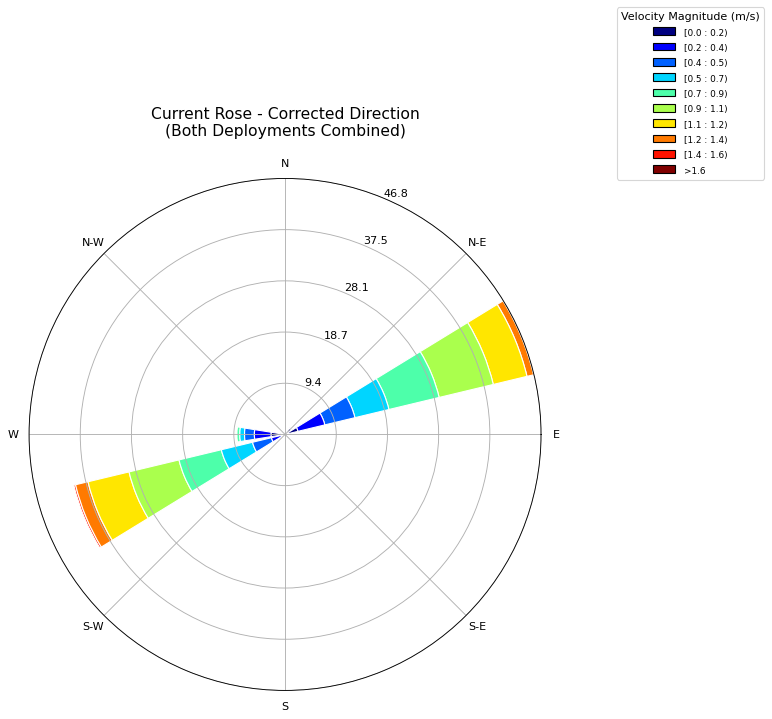

Current rose plot saved as 'current_rose_corrected.png'


In [11]:
# Create current rose plot from corrected direction and magnitude
print("Creating Current Rose Plot from corrected data...")
print()

plt.figure(figsize=(10, 10))
ax = WindroseAxes.from_ax()

# Use corrected direction and magnitude
direction = df_corrected_clean['Dir_num'].values
speed = df_corrected_clean['Mag_num'].values/1000

# Create the current rose
ax.bar(direction, speed, normed=True, opening=0.8, edgecolor='white', cmap=cm.jet, bins=10)
ax.set_legend(title='Velocity Magnitude (m/s)', bbox_to_anchor=(1.15, 1.0))
ax.set_title('Current Rose - Corrected Direction\n(Both Deployments Combined)', fontsize=14, pad=20)

plt.tight_layout()
plt.savefig('current_rose_corrected.png', dpi=300, bbox_inches='tight')
plt.show()

print("Current rose plot saved as 'current_rose_corrected.png'")


In [12]:
# Classify flow as Ebb or Flood using PCA
# Corrected for Long Island Sound geography:
# - FLOOD = WESTWARD flow INTO Sound from Atlantic (~252°T)
# - EBB = EASTWARD flow OUT of Sound to Atlantic (~72°T)

from sklearn.decomposition import PCA

print("Classifying flow direction (Ebb/Flood) using PCA...")
print("Long Island Sound convention: Flood=Westward, Ebb=Eastward")
print()

# Prepare u and v data for PCA
uv_data = df_corrected_clean[['u', 'v']].dropna().to_numpy()

# Perform PCA to find main flow axis
pca = PCA(n_components=2)
pca.fit(uv_data)
main_axis = pca.components_[0]

print(f"Main flow axis (principal component): {main_axis}")
print(f"Explained variance: {pca.explained_variance_ratio_[0]:.2%}")

# Determine bearing of PCA axis (0° = North, 90° = East, etc.)
# main_axis = [u_component, v_component] where u=East, v=North
pca_bearing = np.degrees(np.arctan2(main_axis[0], main_axis[1])) % 360
print(f"PCA axis bearing: {pca_bearing:.2f}°T")

# Determine if PCA axis points toward ebb or flood direction
# Eastward (60-120°) = ebb direction, Westward (240-300°) = flood direction
if 60 <= pca_bearing <= 120:
    axis_direction = "EASTWARD (Ebb)"
    # PCA axis points eastward, so positive projection = ebb, negative = flood
    # We need to flip the axis
    main_axis = -main_axis
    pca_bearing = (pca_bearing + 180) % 360
    print(f"→ PCA axis was pointing EASTWARD (ebb), flipping to WESTWARD (flood)")
    print(f"→ Adjusted axis bearing: {pca_bearing:.2f}°T")
elif 240 <= pca_bearing <= 300:
    axis_direction = "WESTWARD (Flood)"
    print(f"→ PCA axis points WESTWARD (flood direction) ✓")
else:
    print(f"⚠ Warning: PCA axis bearing {pca_bearing:.2f}° is outside expected range")
    print(f"   Expected: 60-120° (eastward/ebb) or 240-300° (westward/flood)")

print()

# Project velocity vectors onto the main axis
# Now: positive projection = westward/flood, negative = eastward/ebb
df_corrected_clean_pca = df_corrected_clean.copy()
uv_for_proj = df_corrected_clean_pca[['u', 'v']].to_numpy()
df_corrected_clean_pca['projected_velocity'] = uv_for_proj @ main_axis

# Define threshold for slack water
slack_threshold = 50  # mm/s (adjust as needed)

# Classify flow direction (now correctly aligned with geography)
def classify_flow(proj_vel):
    if proj_vel > slack_threshold:
        return 'Flood'  # Positive = Westward into Sound
    elif proj_vel < -slack_threshold:
        return 'Ebb'    # Negative = Eastward out to Atlantic
    else:
        return 'Slack'

df_corrected_clean_pca['flow_phase'] = df_corrected_clean_pca['projected_velocity'].apply(classify_flow)

# Count each phase
print("Flow phase classification:")
print(df_corrected_clean_pca['flow_phase'].value_counts())
print()

# Show a sample
print("Sample data with flow phase:")
print(df_corrected_clean_pca[['Dir_num', 'Mag_num', 'u', 'v', 'projected_velocity', 'flow_phase']].head(15))


Classifying flow direction (Ebb/Flood) using PCA...
Long Island Sound convention: Flood=Westward, Ebb=Eastward

Main flow axis (principal component): [0.96753017 0.25275555]
Explained variance: 99.92%
PCA axis bearing: 75.36°T
→ PCA axis was pointing EASTWARD (ebb), flipping to WESTWARD (flood)
→ Adjusted axis bearing: 255.36°T

Flow phase classification:
flow_phase
Flood    8100
Ebb      7966
Slack     476
Name: count, dtype: int64

Sample data with flow phase:
    Dir_num  Mag_num           u           v  projected_velocity flow_phase
2     64.47    197.0  177.764870   84.903775         -193.452775        Ebb
3     57.47    102.0   85.997220   54.849596          -97.068445        Ebb
4     14.47     36.0    8.995430   34.858030          -17.513910      Slack
5    271.47     80.0  -79.973672    2.052282           76.858215      Flood
6    264.47    175.0 -174.185529  -16.864212          172.792278      Flood
7    260.47    272.0 -268.246141  -45.033408          270.918679      Flood
8

In [13]:
# Find dominant direction for Ebb and Flood
print("=" * 60)
print("DOMINANT DIRECTIONS FOR EBB AND FLOOD")
print("=" * 60)
print()

# Separate ebb and flood data
ebb_data = df_corrected_clean_pca[df_corrected_clean_pca['flow_phase'] == 'Ebb']
flood_data = df_corrected_clean_pca[df_corrected_clean_pca['flow_phase'] == 'Flood']

# Method 1: Circular Mean (using sin/cos)
print("Method 1: CIRCULAR MEAN (accounts for wrap-around)")
print("-" * 60)

# Ebb circular mean
ebb_angles_rad = np.deg2rad(ebb_data['Dir_num'].values)
ebb_mean_sin = np.mean(np.sin(ebb_angles_rad))
ebb_mean_cos = np.mean(np.cos(ebb_angles_rad))
ebb_circ_mean = np.degrees(np.arctan2(ebb_mean_sin, ebb_mean_cos)) % 360

# Flood circular mean
flood_angles_rad = np.deg2rad(flood_data['Dir_num'].values)
flood_mean_sin = np.mean(np.sin(flood_angles_rad))
flood_mean_cos = np.mean(np.cos(flood_angles_rad))
flood_circ_mean = np.degrees(np.arctan2(flood_mean_sin, flood_mean_cos)) % 360

print(f"Ebb dominant direction:   {ebb_circ_mean:7.2f}°")
print(f"Flood dominant direction: {flood_circ_mean:7.2f}°")
print(f"Difference:               {abs(ebb_circ_mean - flood_circ_mean):7.2f}°")
print()

# Method 2: Arithmetic Mean (simple average)
print("Method 2: ARITHMETIC MEAN (simple average)")
print("-" * 60)

ebb_arith_mean = ebb_data['Dir_num'].mean()
flood_arith_mean = flood_data['Dir_num'].mean()

print(f"Ebb dominant direction:   {ebb_arith_mean:7.2f}°")
print(f"Flood dominant direction: {flood_arith_mean:7.2f}°")
print(f"Difference:               {abs(ebb_arith_mean - flood_arith_mean):7.2f}°")
print()

# Method 3: Vector Mean (using u, v components)
print("Method 3: VECTOR MEAN (from u/v components)")
print("-" * 60)

ebb_u_mean = ebb_data['u'].mean()
ebb_v_mean = ebb_data['v'].mean()
ebb_vector_dir = np.degrees(np.arctan2(ebb_u_mean, ebb_v_mean)) % 360

flood_u_mean = flood_data['u'].mean()
flood_v_mean = flood_data['v'].mean()
flood_vector_dir = np.degrees(np.arctan2(flood_u_mean, flood_v_mean)) % 360

print(f"Ebb dominant direction:   {ebb_vector_dir:7.2f}° (from mean u={ebb_u_mean:.1f}, v={ebb_v_mean:.1f})")
print(f"Flood dominant direction: {flood_vector_dir:7.2f}° (from mean u={flood_u_mean:.1f}, v={flood_v_mean:.1f})")
print(f"Difference:               {abs(ebb_vector_dir - flood_vector_dir):7.2f}°")
print()


DOMINANT DIRECTIONS FOR EBB AND FLOOD

Method 1: CIRCULAR MEAN (accounts for wrap-around)
------------------------------------------------------------
Ebb dominant direction:     72.38°
Flood dominant direction:  257.78°
Difference:                185.40°

Method 2: ARITHMETIC MEAN (simple average)
------------------------------------------------------------
Ebb dominant direction:     72.35°
Flood dominant direction:  257.80°
Difference:                185.45°

Method 3: VECTOR MEAN (from u/v components)
------------------------------------------------------------
Ebb dominant direction:     73.79° (from mean u=686.2, v=199.5)
Flood dominant direction:  256.71° (from mean u=-725.0, v=-171.3)
Difference:                182.92°



Creating current rose plots for Ebb and Flood phases...



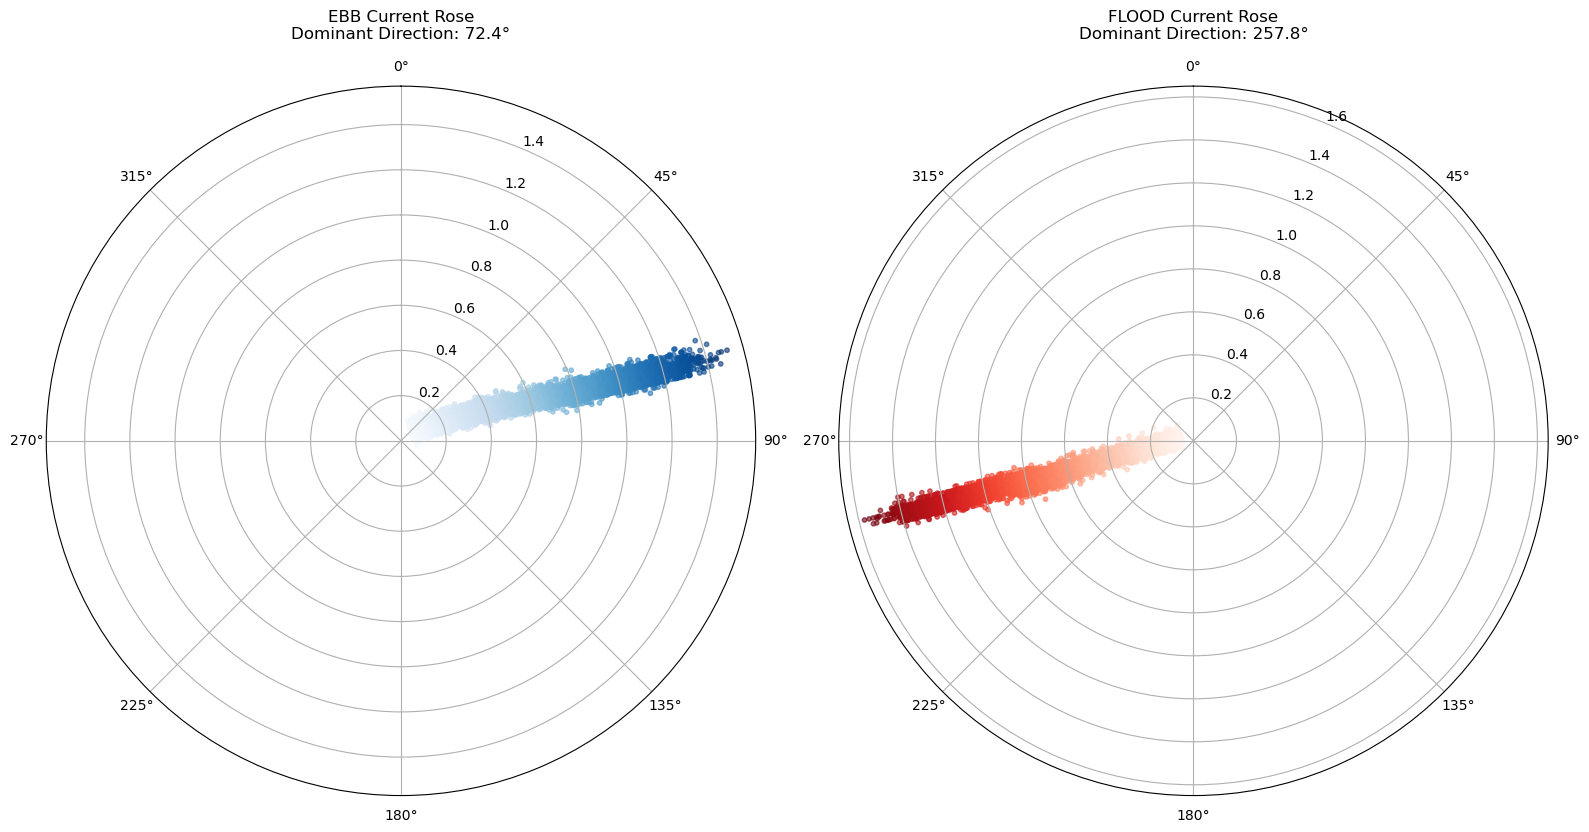

Current rose comparison plot saved as 'current_rose_ebb_flood.png'

SUMMARY - Dominant Directions:
Ebb:    7966 samples, dominant direction =   72.38°
Flood:  8100 samples, dominant direction =  257.78°
Difference between ebb and flood:  185.40°


In [14]:
# Create side-by-side current rose plots for Ebb and Flood
print("Creating current rose plots for Ebb and Flood phases...")
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection='polar'))

# Ebb current rose
ebb_direction = np.deg2rad(ebb_data['Dir_num'].values)
ebb_speed = ebb_data['Mag_num'].values / 1000  # Convert to m/s
ax1.scatter(ebb_direction, ebb_speed, c=ebb_speed, s=10, alpha=0.6, cmap=cm.Blues)
ax1.set_title(f'EBB Current Rose\nDominant Direction: {ebb_circ_mean:.1f}°', fontsize=12, pad=15)
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)

# Flood current rose
flood_direction = np.deg2rad(flood_data['Dir_num'].values)
flood_speed = flood_data['Mag_num'].values / 1000  # Convert to m/s
ax2.scatter(flood_direction, flood_speed, c=flood_speed, s=10, alpha=0.6, cmap=cm.Reds)
ax2.set_title(f'FLOOD Current Rose\nDominant Direction: {flood_circ_mean:.1f}°', fontsize=12, pad=15)
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

plt.tight_layout()
plt.savefig('current_rose_ebb_flood.png', dpi=300, bbox_inches='tight')
plt.show()

print("Current rose comparison plot saved as 'current_rose_ebb_flood.png'")
print()
print("SUMMARY - Dominant Directions:")
print("=" * 60)
print(f"Ebb:   {len(ebb_data):5d} samples, dominant direction = {ebb_circ_mean:7.2f}°")
print(f"Flood: {len(flood_data):5d} samples, dominant direction = {flood_circ_mean:7.2f}°")
print(f"Difference between ebb and flood: {abs(ebb_circ_mean - flood_circ_mean):7.2f}°")
